In [3]:
# ============================================================
# Employee Attrition Prediction - Model Building & Evaluation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Load the processed data from previous notebook
X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")
feature_names = joblib.load("../data/processed/feature_names.pkl")

print("Data loaded successfully!")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")
print(f"Number of features: {len(feature_names)}")

Data loaded successfully!
X_train: (1972, 56)
X_test : (294, 56)
y_train: (1972,)
y_test : (294,)
Number of features: 56


In [5]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluate a model and return key metrics.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }

    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))
    
    print(f"ROC-AUC : {metrics['ROC-AUC']:.4f}")
    print(f"PR-AUC  : {metrics['PR-AUC']:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Attrition", "Attrition"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return metrics, y_pred, y_proba

Training Logistic Regression...

Logistic Regression Results
              precision    recall  f1-score   support

No Attrition       0.92      0.80      0.85       247
   Attrition       0.38      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.83      0.77      0.79       294

ROC-AUC : 0.8092
PR-AUC  : 0.5433


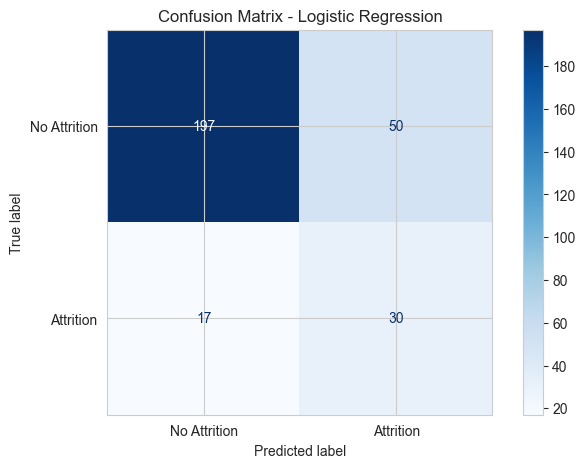

In [6]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_model.fit(X_train, y_train)

lr_metrics, lr_pred, lr_proba = evaluate_model(lr_model, X_test, y_test, "Logistic Regression")

Training Random Forest...

Random Forest Results
              precision    recall  f1-score   support

No Attrition       0.88      0.96      0.92       247
   Attrition       0.58      0.30      0.39        47

    accuracy                           0.85       294
   macro avg       0.73      0.63      0.66       294
weighted avg       0.83      0.85      0.83       294

ROC-AUC : 0.8139
PR-AUC  : 0.5112


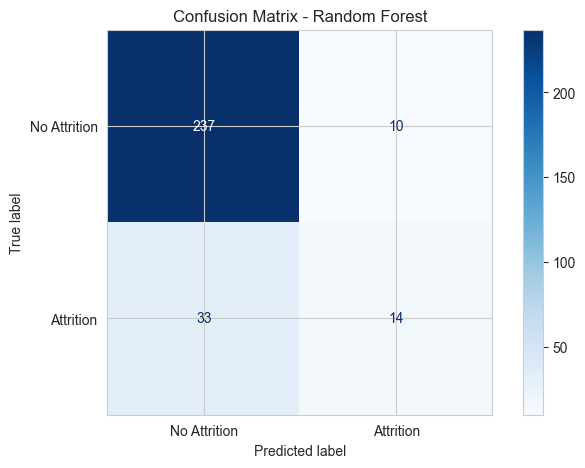

In [7]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_metrics, rf_pred, rf_proba = evaluate_model(rf_model, X_test, y_test, "Random Forest")

Training XGBoost...

XGBoost Results
              precision    recall  f1-score   support

No Attrition       0.88      0.97      0.92       247
   Attrition       0.64      0.30      0.41        47

    accuracy                           0.86       294
   macro avg       0.76      0.63      0.66       294
weighted avg       0.84      0.86      0.84       294

ROC-AUC : 0.7884
PR-AUC  : 0.5101


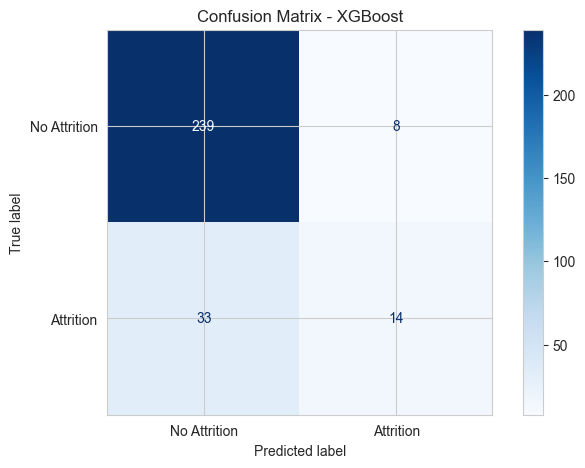

In [8]:
print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

xgb_metrics, xgb_pred, xgb_proba = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

Training LightGBM...

LightGBM Results
              precision    recall  f1-score   support

No Attrition       0.87      0.97      0.92       247
   Attrition       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294

ROC-AUC : 0.7685
PR-AUC  : 0.4717


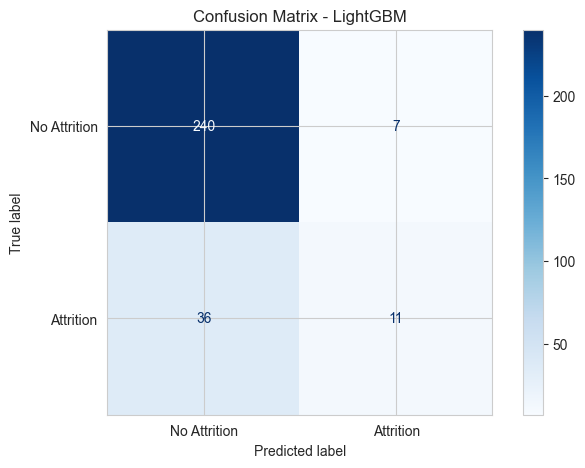

In [9]:
print("Training LightGBM...")

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

lgbm_metrics, lgbm_pred, lgbm_proba = evaluate_model(lgbm_model, X_test, y_test, "LightGBM")

In [10]:
# Create comparison DataFrame
results_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics, lgbm_metrics])
results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
display(results_df.style.highlight_max(axis=0, color="lightgreen").format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
}))


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.8537,0.5833,0.2979,0.3944,0.8139,0.5112
1,Logistic Regression,0.7721,0.3750,0.6383,0.4724,0.8092,0.5433
2,XGBoost,0.8605,0.6364,0.2979,0.4058,0.7884,0.5101
3,LightGBM,0.8537,0.6111,0.2340,0.3385,0.7685,0.4717


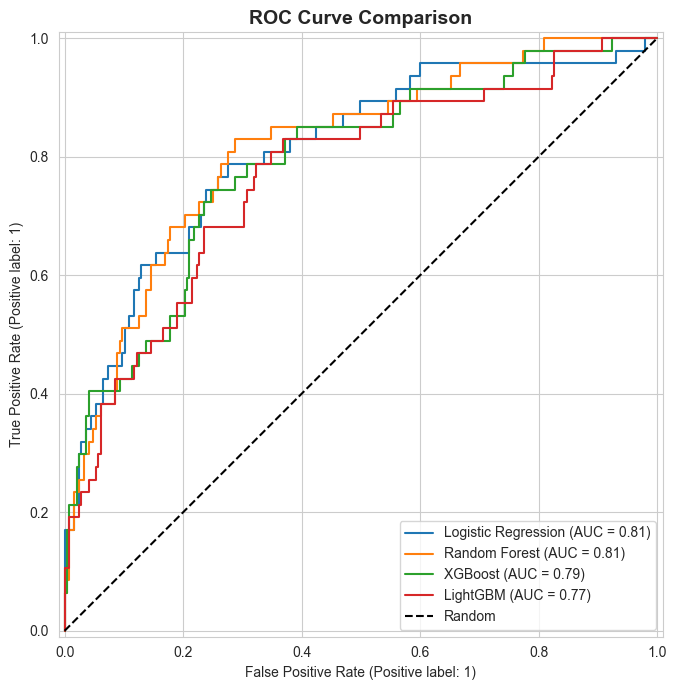

In [11]:
plt.figure(figsize=(10, 7))

RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, xgb_proba, name="XGBoost", ax=plt.gca())
RocCurveDisplay.from_predictions(y_test, lgbm_proba, name="LightGBM", ax=plt.gca())

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title("ROC Curve Comparison", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

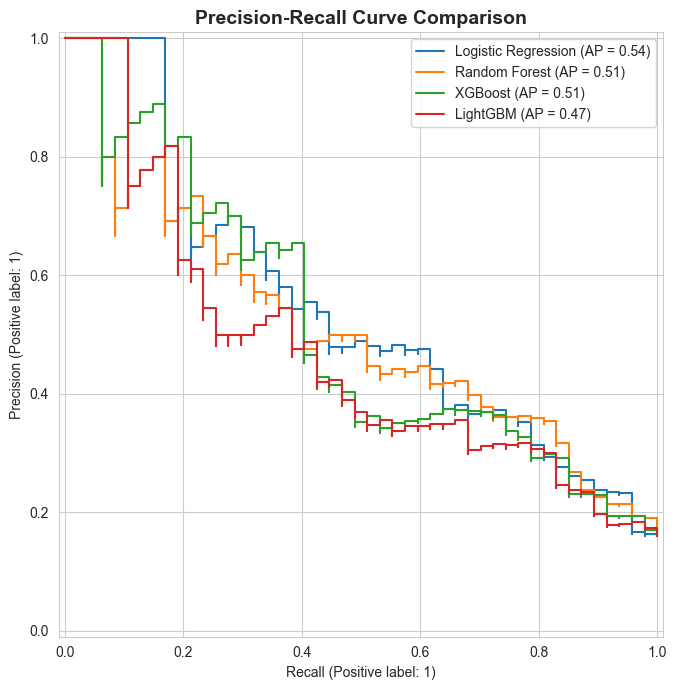

In [12]:
plt.figure(figsize=(10, 7))

PrecisionRecallDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, xgb_proba, name="XGBoost", ax=plt.gca())
PrecisionRecallDisplay.from_predictions(y_test, lgbm_proba, name="LightGBM", ax=plt.gca())

plt.title("Precision-Recall Curve Comparison", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Select the best model based on ROC-AUC
best_model_name = results_df.iloc[0]["Model"]
print(f"Best Model: {best_model_name}")

if best_model_name == "Logistic Regression":
    best_model = lr_model
elif best_model_name == "Random Forest":
    best_model = rf_model
elif best_model_name == "XGBoost":
    best_model = xgb_model
else:
    best_model = lgbm_model

# Save the best model
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/best_model.pkl")

# Also save all models (optional)
joblib.dump(lr_model, "../models/logistic_regression.pkl")
joblib.dump(rf_model, "../models/random_forest.pkl")
joblib.dump(xgb_model, "../models/xgboost.pkl")
joblib.dump(lgbm_model, "../models/lightgbm.pkl")

print("\nBest model and all models saved successfully in ../models/")

Best Model: Random Forest

Best model and all models saved successfully in ../models/


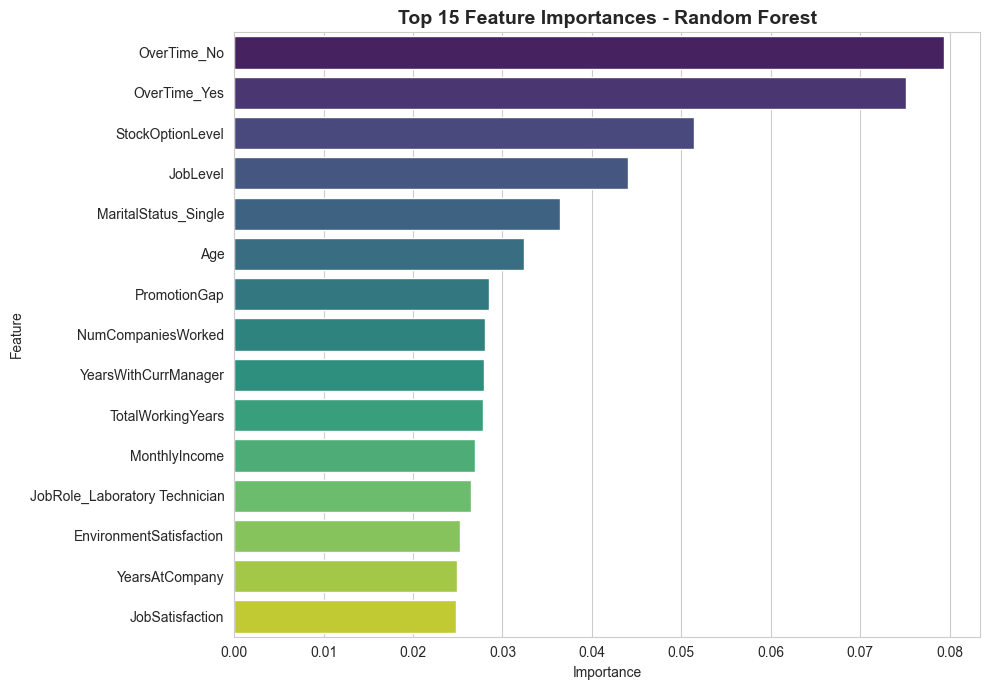


Top 15 Important Features:


,Feature,Importance
54,OverTime_No,0.079423
55,OverTime_Yes,0.075072
15,StockOptionLevel,0.051418
7,JobLevel,0.044036
53,MaritalStatus_Single,0.036433
0,Age,0.032408
26,PromotionGap,0.028548
11,NumCompaniesWorked,0.027994
22,YearsWithCurrManager,0.027965
16,TotalWorkingYears,0.027847


In [14]:
# Show feature importance for the best tree-based model
if best_model_name in ["Random Forest", "XGBoost", "LightGBM"]:
    
    if best_model_name == "Random Forest":
        importances = best_model.feature_importances_
    elif best_model_name == "XGBoost":
        importances = best_model.feature_importances_
    else:
        importances = best_model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
    plt.title(f"Top 15 Feature Importances - {best_model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nTop 15 Important Features:")
    display(importance_df)
else:
    print("Feature importance plot is shown for tree-based models only.")

In [15]:
print("="*60)
print("MODELING COMPLETED")
print("="*60)

print(f"""
Best Model          : {best_model_name}
Best ROC-AUC        : {results_df.iloc[0]['ROC-AUC']:.4f}
Best PR-AUC         : {results_df.iloc[0]['PR-AUC']:.4f}
Best F1-Score       : {results_df.iloc[0]['F1-Score']:.4f}

Models saved in     : ../models/
Best model path     : ../models/best_model.pkl
""")

MODELING COMPLETED

Best Model          : Random Forest
Best ROC-AUC        : 0.8139
Best PR-AUC         : 0.5112
Best F1-Score       : 0.3944

Models saved in     : ../models/
Best model path     : ../models/best_model.pkl

